# Lecture 18: Unsupervised Machine Learning & K-Means Clustering

**F&W ECOL 458 — Environmental Data Science**

Reference: [scikit-learn Clustering documentation](https://scikit-learn.org/stable/modules/clustering.html)

---

### Learning objectives

By the end of this lecture you should be able to:

1. Distinguish supervised from unsupervised learning and explain when each is appropriate.
2. Describe the K-Means algorithm step by step.
3. Implement K-Means in `scikit-learn` and interpret the results.
4. Use the Elbow Method and Silhouette Score to choose $k$.
5. Recognize the limitations of K-Means and when other clustering methods may be needed.
6. Apply K-Means to satellite imagery for unsupervised land-cover classification.


## 1. The Shift: From Labels to Discovery

In Lectures 14–17, every algorithm we used was **supervised** — we had labeled training data and the goal was to predict those labels for new observations.

But what if you **don't have labels**?

| Scenario | Labels? | Approach |
|---|---|---|
| "Classify this pixel as forest, water, or urban" | Yes — you collected training samples | Supervised (SVM, KNN, NB) |
| "I have 10,000 pixels — are there natural groupings I haven't noticed?" | No labels at all | **Unsupervised** |
| "I have a new satellite sensor — what spectral classes exist in this landscape?" | No prior knowledge | **Unsupervised** |

In unsupervised learning, the algorithm discovers **structure** in the data on its own — no human-provided labels needed.

### Real-world examples where unsupervised learning shines

- **Ecological community analysis:** You survey 200 prairie plots and measure 50 plant species. Are there distinct community types, or is it a continuum? Clustering can reveal groups.
- **Remote sensing:** Before doing a supervised classification, you want to know how many spectrally distinct classes exist in your image. Unsupervised classification can tell you.
- **Anomaly detection:** Identify unusual sensor readings at a flux tower that might indicate instrument malfunction.
- **Customer segmentation, gene expression analysis, document clustering...** — the same ideas work across domains.


## 2. What is Clustering?

**Clustering** is the most common unsupervised learning task: group data points so that points within the same cluster are **more similar** to each other than to points in other clusters.

Think of it this way: imagine dumping a bag of mixed candies on a table. Without anyone telling you the candy names, you would naturally sort them into piles by color, shape, and size. That's clustering.

The key question is: **what does "similar" mean?** For numerical data, similarity is usually defined by **distance** (Euclidean, Manhattan, etc.) — the same concept we used in KNN.


## 3. K-Means: The Intuition

### The party analogy

Imagine you're organizing a large outdoor picnic for 100 guests in a park. You need to set up **$k$ food stations** so that no guest has to walk too far to get food. Where do you place them?

1. **Start by guessing:** Place $k$ food stations at random spots in the park.
2. **Assign guests:** Each guest walks to the **nearest** food station.
3. **Adjust stations:** Move each food station to the **center** of the guests assigned to it — this minimizes total walking distance.
4. **Repeat:** Guests might now be closer to a different station, so reassign and re-center. Keep going until nobody switches stations.

That's K-Means! Replace "guests" with "data points" and "food stations" with "cluster centroids."


## 4. The K-Means Algorithm

Formally, given $N$ data points and a desired number of clusters $k$:

**Step 1 — Initialize:** Randomly place $k$ centroids $\boldsymbol{\mu}_1, \ldots, \boldsymbol{\mu}_k$ in feature space.

**Step 2 — Assign:** Assign each data point $\mathbf{x}_i$ to the nearest centroid:

$$
c_i = \arg\min_j \; \|\mathbf{x}_i - \boldsymbol{\mu}_j\|^2
$$

**Step 3 — Update:** Recompute each centroid as the mean of all points assigned to it:

$$
\boldsymbol{\mu}_j = \frac{1}{|C_j|} \sum_{\mathbf{x}_i \in C_j} \mathbf{x}_i
$$

**Step 4 — Repeat** Steps 2–3 until the assignments stop changing (convergence).

The algorithm minimizes the **within-cluster sum of squares (WCSS)**, also called **inertia**:

$$
\text{WCSS} = \sum_{j=1}^{k} \sum_{\mathbf{x}_i \in C_j} \|\mathbf{x}_i - \boldsymbol{\mu}_j\|^2
$$

Let's watch this happen step by step.


### Watching K-Means converge


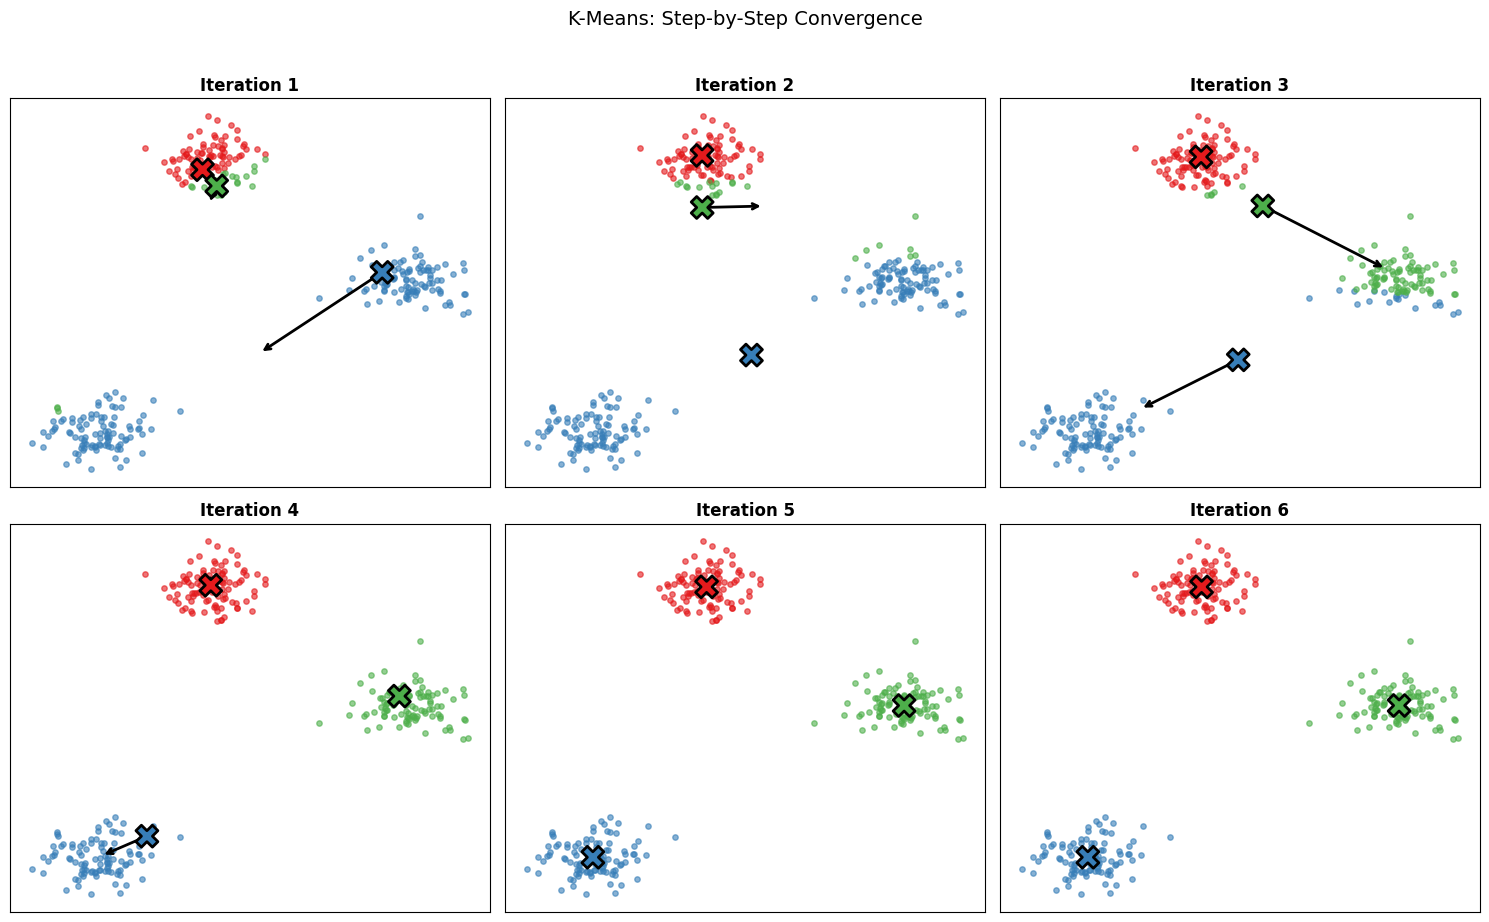

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

# ── Generate synthetic data: 3 clusters ──
np.random.seed(42)
X, y_true = make_blobs(n_samples=300, centers=3, cluster_std=1.0, random_state=42)

# ── Manual K-Means implementation for visualization ──
k = 3

# Step 1: Random initialization
rng = np.random.RandomState(10)
centroids = X[rng.choice(len(X), k, replace=False)]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.ravel()
colors = ['#e41a1c', '#377eb8', '#4daf4a']

for iteration in range(6):
    ax = axes[iteration]

    # Step 2: Assign each point to nearest centroid
    distances = np.array([np.linalg.norm(X - c, axis=1) for c in centroids])
    labels = distances.argmin(axis=0)

    # Plot points colored by assignment
    for j in range(k):
        mask = labels == j
        ax.scatter(X[mask, 0], X[mask, 1], c=colors[j], s=15, alpha=0.6)

    # Plot centroids
    ax.scatter(centroids[:, 0], centroids[:, 1], c=colors[:k],
               s=250, marker='X', edgecolors='k', linewidths=2, zorder=5)

    ax.set_title(f'Iteration {iteration + 1}', fontsize=12, fontweight='bold')
    ax.set_xticks([])
    ax.set_yticks([])

    # Step 3: Update centroids
    new_centroids = np.array([X[labels == j].mean(axis=0) for j in range(k)])

    # Draw arrows showing centroid movement
    for old, new in zip(centroids, new_centroids):
        if np.linalg.norm(new - old) > 0.05:
            ax.annotate('', xy=new, xytext=old,
                        arrowprops=dict(arrowstyle='->', color='black',
                                        linewidth=2, shrinkA=5, shrinkB=5))

    centroids = new_centroids

plt.suptitle('K-Means: Step-by-Step Convergence', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


Each panel shows one iteration. The large **X** markers are the centroids, and the arrows show how centroids move toward the center of their assigned points. By iteration 3–4, the centroids barely move — the algorithm has converged.

Notice that K-Means found the three clusters without ever seeing the true labels — it discovered the structure purely from the data.


## 5. K-Means in `scikit-learn`

In practice you don't implement K-Means by hand — `scikit-learn` handles initialization, convergence, and multiple restarts for you.


Cluster sizes: [100 100 100]
Inertia (WCSS): 566.9
Centroids:
[[-2.63  9.04]
 [-6.88 -6.98]
 [ 4.75  2.01]]


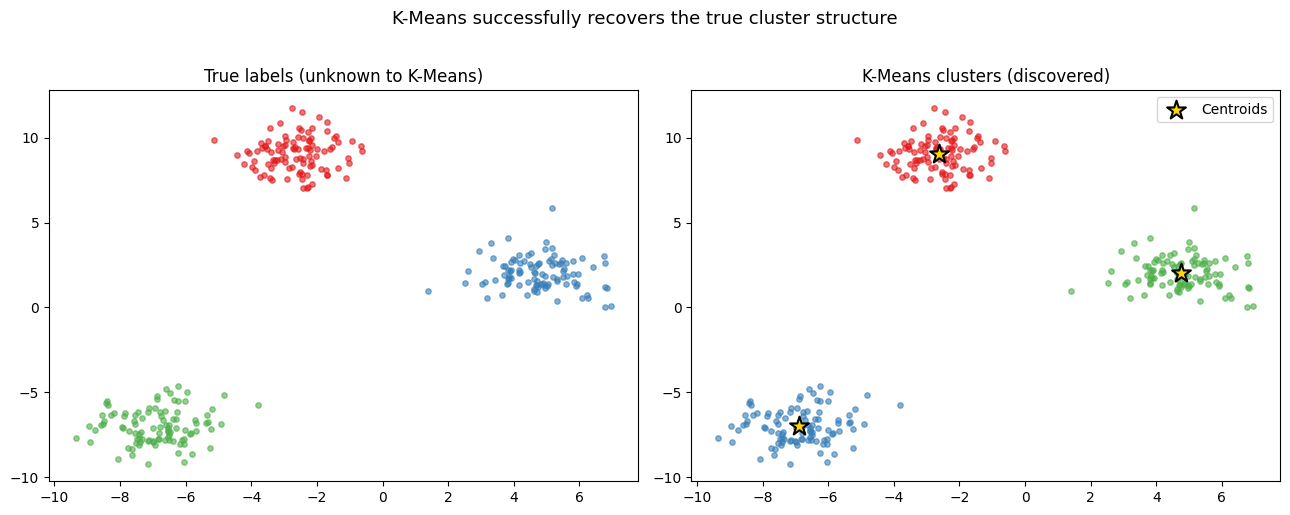

In [ ]:
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
import numpy as np

# ── Generate data ──
X, y_true = make_blobs(n_samples=300, centers=3, cluster_std=1.0, random_state=42)

# ── Fit K-Means ──
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans.fit(X)

# ── Results ──
labels = kmeans.labels_         # Cluster assignment for each point
centroids = kmeans.cluster_centers_  # Final centroid locations
inertia = kmeans.inertia_       # Within-cluster sum of squares

print(f"Cluster sizes: {np.bincount(labels)}")
print(f"Inertia (WCSS): {inertia:.1f}")
print(f"Centroids:\n{centroids.round(2)}")

# ── Plot ──
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors_map = ['#e41a1c', '#377eb8', '#4daf4a']

# Left: true labels
for j in range(3):
    mask = y_true == j
    axes[0].scatter(X[mask, 0], X[mask, 1], c=colors_map[j], s=15, alpha=0.6)
axes[0].set_title("True labels (unknown to K-Means)")

# Right: K-Means result
for j in range(3):
    mask = labels == j
    axes[1].scatter(X[mask, 0], X[mask, 1], c=colors_map[j], s=15, alpha=0.6)
axes[1].scatter(centroids[:, 0], centroids[:, 1], c='gold', s=200,
                marker='*', edgecolors='k', linewidths=1.5, zorder=5,
                label='Centroids')
axes[1].set_title("K-Means clusters (discovered)")
axes[1].legend()

plt.suptitle("K-Means successfully recovers the true cluster structure",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


The cluster colors may be permuted (K-Means doesn't know which cluster is "cluster 0" vs. "cluster 1"), but the groupings match the true structure.


## 6. Choosing $k$: How Many Clusters?

K-Means requires you to specify $k$ in advance — but how do you know the right number of clusters? Two widely used methods:

### Method 1: The Elbow Method

Plot **inertia (WCSS)** as a function of $k$. As $k$ increases, inertia always decreases (more clusters = tighter fit). The "elbow" is the point where adding more clusters stops providing much improvement — that's a good $k$.

### Method 2: Silhouette Score

The **silhouette score** measures how similar each point is to its own cluster compared to the nearest neighboring cluster. It ranges from $-1$ (wrong cluster) to $+1$ (perfectly clustered). Higher is better.


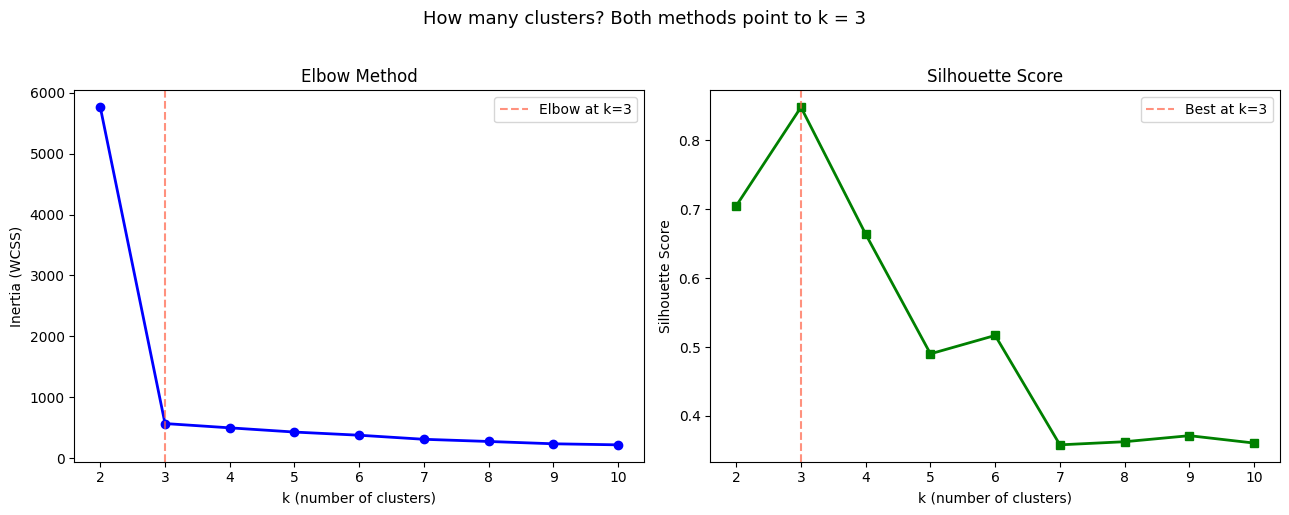

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import numpy as np

# ── Try k = 2 to 10 ──
k_range = range(2, 11)
inertias = []
silhouettes = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X, km.labels_))

# ── Plot ──
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Elbow plot
axes[0].plot(list(k_range), inertias, 'bo-', linewidth=2)
axes[0].axvline(3, color='tomato', linestyle='--', alpha=0.7, label='Elbow at k=3')
axes[0].set_xlabel('k (number of clusters)')
axes[0].set_ylabel('Inertia (WCSS)')
axes[0].set_title('Elbow Method')
axes[0].legend()

# Silhouette plot
axes[1].plot(list(k_range), silhouettes, 'gs-', linewidth=2)
axes[1].axvline(3, color='tomato', linestyle='--', alpha=0.7, label='Best at k=3')
axes[1].set_xlabel('k (number of clusters)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score')
axes[1].legend()

plt.suptitle('How many clusters? Both methods point to k = 3', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


For our synthetic data, both methods clearly point to $k = 3$. In real data the elbow is often less sharp — use both methods together, and combine with domain knowledge (e.g., "we expect 4–6 land-cover classes in this region").


### What happens with the wrong $k$?


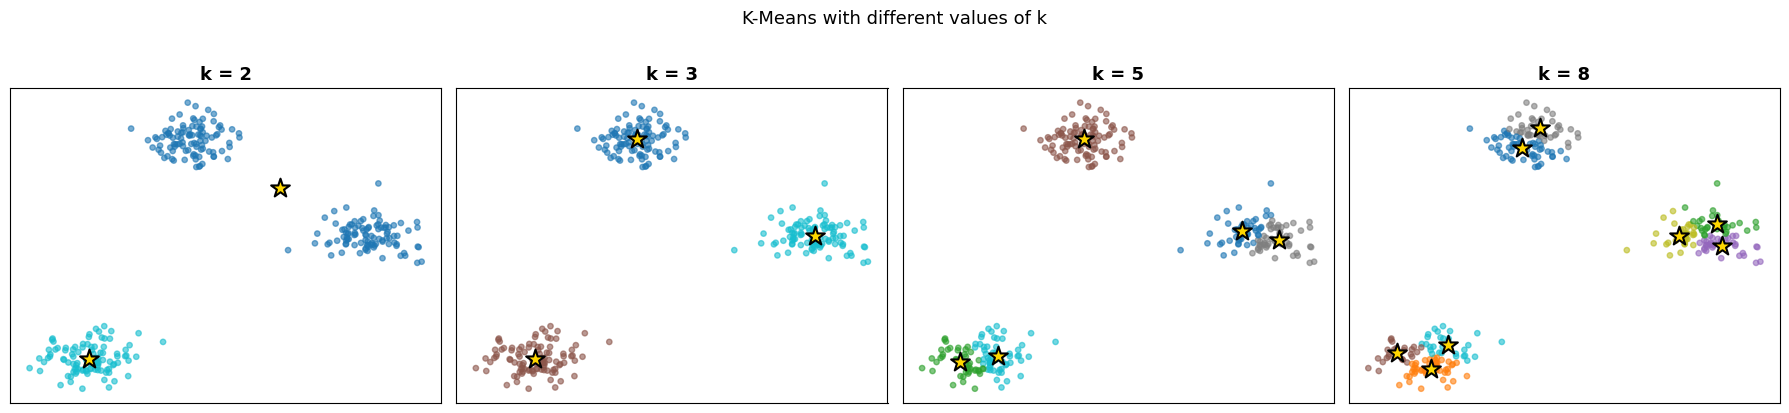

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, k in zip(axes, [2, 3, 5, 8]):
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X)
    ax.scatter(X[:, 0], X[:, 1], c=km.labels_, cmap='tab10', s=15, alpha=0.6)
    ax.scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1],
               c='gold', s=200, marker='*', edgecolors='k', linewidths=1.5, zorder=5)
    ax.set_title(f'k = {k}', fontsize=13, fontweight='bold')
    ax.set_xticks([])
    ax.set_yticks([])

plt.suptitle('K-Means with different values of k', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


- **$k = 2$:** Under-clustering — two natural groups are merged into one.
- **$k = 3$:** Just right — matches the true structure.
- **$k = 5, 8$:** Over-clustering — real clusters are artificially split. This can happen in practice when you set $k$ too high.


## 7. When K-Means Struggles

K-Means makes some strong assumptions. When those assumptions are violated, it can fail badly.

### Assumption 1: Clusters are spherical (isotropic)

K-Means assigns points to the nearest centroid using Euclidean distance, which implicitly assumes clusters are roughly **round**. Elongated, ring-shaped, or irregular clusters break this assumption.

### Assumption 2: Clusters are similar in size

K-Means tends to produce clusters of roughly equal spatial extent. If one cluster is much larger or denser than another, K-Means may split the big cluster and merge small ones.

### Assumption 3: You know $k$ in advance

In ecological data, the "true" number of groups is often unknown or may not even be a well-defined number.

Let's see what happens with non-spherical data:


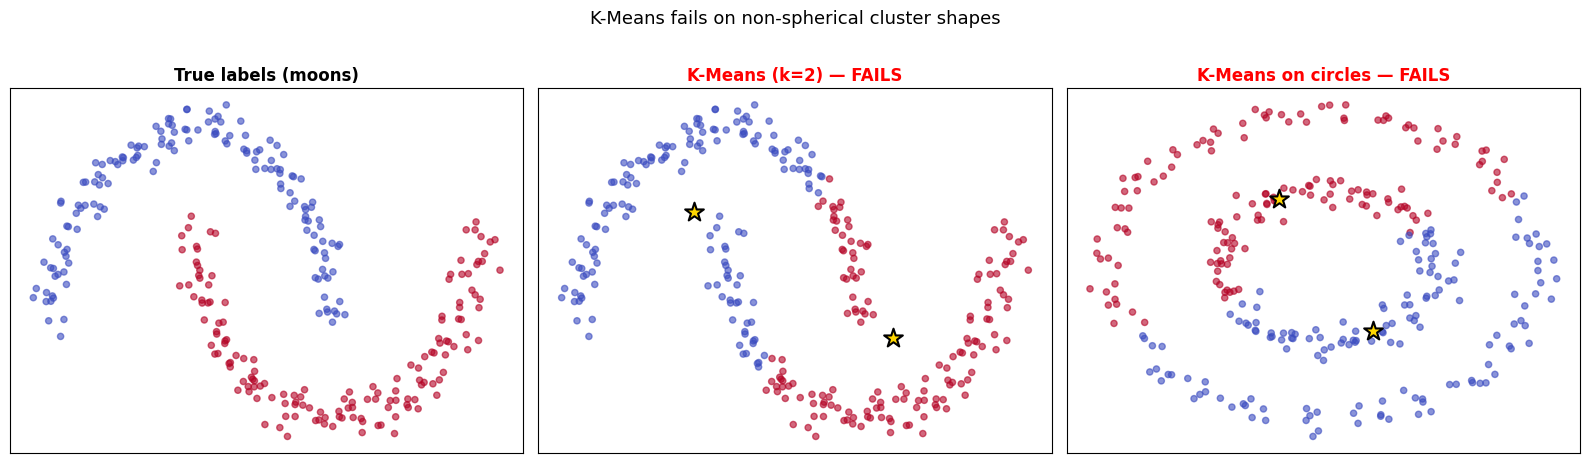

In [ ]:
from sklearn.datasets import make_moons, make_circles
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# ── Half moons ──
X_moons, y_moons = make_moons(n_samples=300, noise=0.06, random_state=42)
km_moons = KMeans(n_clusters=2, random_state=42, n_init=10).fit(X_moons)

axes[0].scatter(X_moons[:, 0], X_moons[:, 1], c=y_moons, cmap='coolwarm', s=20, alpha=0.6)
axes[0].set_title('True labels (moons)', fontweight='bold')

axes[1].scatter(X_moons[:, 0], X_moons[:, 1], c=km_moons.labels_, cmap='coolwarm', s=20, alpha=0.6)
axes[1].scatter(km_moons.cluster_centers_[:, 0], km_moons.cluster_centers_[:, 1],
                c='gold', s=200, marker='*', edgecolors='k', linewidths=1.5, zorder=5)
axes[1].set_title('K-Means (k=2) — FAILS', fontweight='bold', color='red')

# ── Concentric circles ──
X_circ, y_circ = make_circles(n_samples=300, factor=0.5, noise=0.05, random_state=42)
km_circ = KMeans(n_clusters=2, random_state=42, n_init=10).fit(X_circ)

axes[2].scatter(X_circ[:, 0], X_circ[:, 1], c=km_circ.labels_, cmap='coolwarm', s=20, alpha=0.6)
axes[2].scatter(km_circ.cluster_centers_[:, 0], km_circ.cluster_centers_[:, 1],
                c='gold', s=200, marker='*', edgecolors='k', linewidths=1.5, zorder=5)
axes[2].set_title('K-Means on circles — FAILS', fontweight='bold', color='red')

for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])

plt.suptitle("K-Means fails on non-spherical cluster shapes", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


K-Means splits both the moons and the circles with a vertical cut — because it can only draw boundaries based on distance to centroids. For non-convex shapes like these, you would need algorithms like **DBSCAN** or **spectral clustering** (beyond the scope of this course, but good to know they exist).

> **Ecological takeaway:** K-Means works well for spectrally distinct land-cover classes (which tend to form blobs in spectral feature space), but may struggle with gradients or ecotones where communities blend into each other.


## 8. Ecological Application: Unsupervised Classification of Satellite Imagery

One of the most common uses of K-Means in environmental science is **unsupervised classification** of satellite imagery. Instead of providing training samples, you let the algorithm discover the spectrally distinct classes in the image.

This is useful when:
- You don't have ground truth / training data.
- You want to explore what spectral classes exist before doing a supervised classification.
- You need a quick first look at a new study area.

### K-Means on Landsat spectral data

Let's simulate this with real Landsat-scale spectral data. We'll create synthetic "pixels" that mimic the spectral signatures of four land-cover types:


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

np.random.seed(42)

# ── Simulate Landsat-like spectral signatures for 4 land-cover types ──
# Each pixel has 6 bands: Blue, Green, Red, NIR, SWIR1, SWIR2
# Values are surface reflectance * 10000

n_per_class = 200

# Water: low across all bands, especially NIR
water = np.random.normal(
    loc=[800, 900, 700, 400, 200, 150],
    scale=[100, 100, 100, 80, 50, 40],
    size=(n_per_class, 6)
)

# Forest: low visible, very high NIR, moderate SWIR
forest = np.random.normal(
    loc=[500, 600, 400, 3500, 1800, 800],
    scale=[80, 80, 80, 400, 300, 150],
    size=(n_per_class, 6)
)

# Agriculture: moderate visible, high NIR (but less than forest), high SWIR
agriculture = np.random.normal(
    loc=[700, 800, 650, 2800, 2200, 1200],
    scale=[100, 100, 100, 350, 350, 200],
    size=(n_per_class, 6)
)

# Urban/bare soil: high visible, moderate NIR, high SWIR
urban = np.random.normal(
    loc=[1200, 1300, 1400, 1800, 2500, 2200],
    scale=[200, 200, 200, 300, 400, 350],
    size=(n_per_class, 6)
)

X_spectral = np.vstack([water, forest, agriculture, urban])
y_true_spectral = np.array([0]*n_per_class + [1]*n_per_class +
                            [2]*n_per_class + [3]*n_per_class)
band_names = ['Blue', 'Green', 'Red', 'NIR', 'SWIR1', 'SWIR2']
class_names = ['Water', 'Forest', 'Agriculture', 'Urban']

print(f"Simulated {len(X_spectral)} pixels with {X_spectral.shape[1]} spectral bands")
print(f"True classes: {', '.join(class_names)}")


Simulated 800 pixels with 6 spectral bands
True classes: Water, Forest, Agriculture, Urban


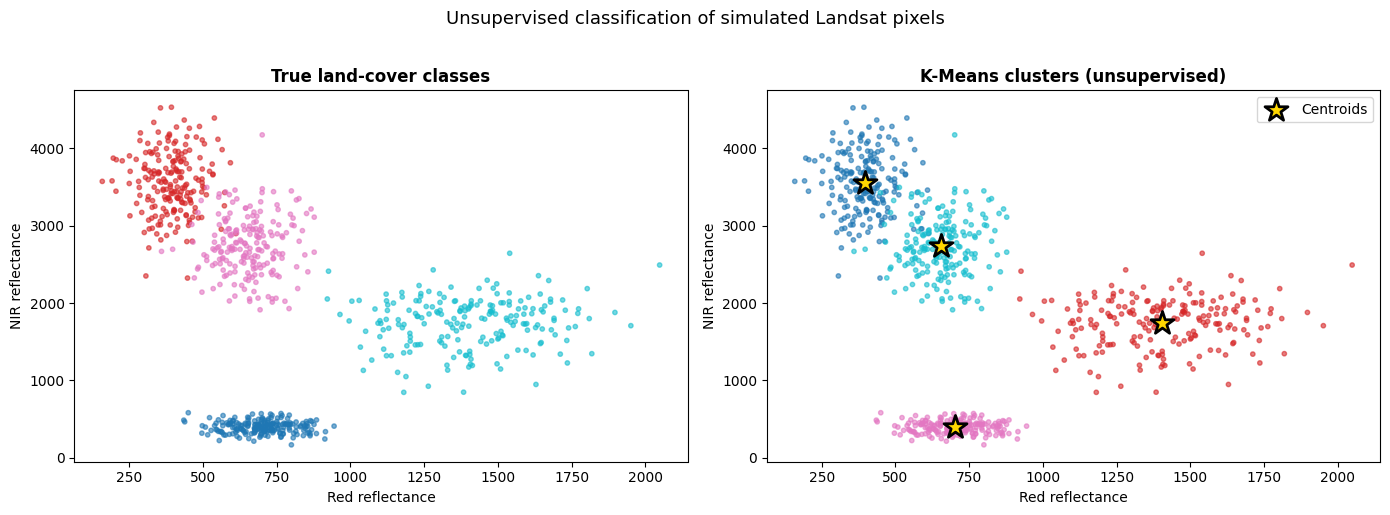

In [ ]:
# ── Run K-Means (unsupervised — no labels used!) ──
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_spectral)

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans.fit(X_scaled)
pred_labels = kmeans.labels_

# ── Compare: true labels vs. K-Means clusters ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#1f78b4', '#33a02c', '#ffff99', '#e31a1c']
cmap_true = plt.cm.colors.ListedColormap(colors)

# Plot in NIR vs. Red space (classic remote sensing axes)
nir_idx, red_idx = 3, 2

for ax, labels_arr, title in zip(axes,
                                  [y_true_spectral, pred_labels],
                                  ['True land-cover classes', 'K-Means clusters (unsupervised)']):
    scatter = ax.scatter(X_spectral[:, red_idx], X_spectral[:, nir_idx],
                         c=labels_arr, cmap='tab10', s=10, alpha=0.6)
    ax.set_xlabel('Red reflectance')
    ax.set_ylabel('NIR reflectance')
    ax.set_title(title, fontweight='bold')

# Add centroids to K-Means plot (transform back to original scale)
centroids_orig = scaler.inverse_transform(kmeans.cluster_centers_)
axes[1].scatter(centroids_orig[:, red_idx], centroids_orig[:, nir_idx],
                c='gold', s=300, marker='*', edgecolors='k', linewidths=2, zorder=5,
                label='Centroids')
axes[1].legend()

plt.suptitle('Unsupervised classification of simulated Landsat pixels',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


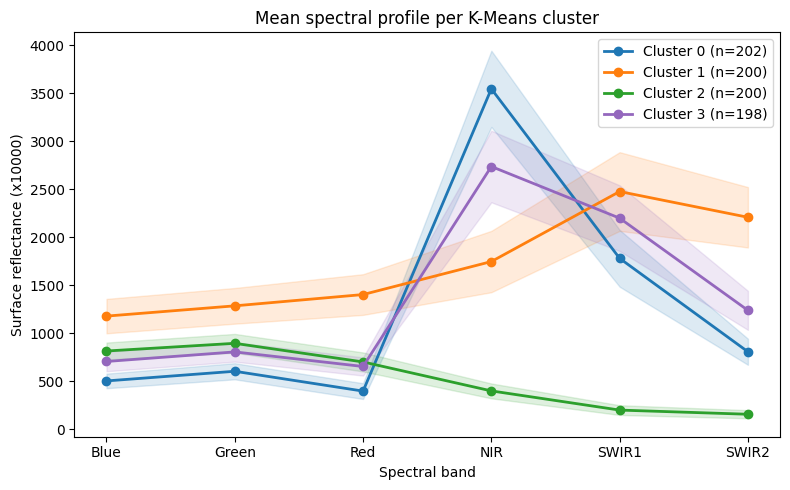

Interpret the clusters by their spectral signatures:
  - Low across all bands, especially NIR → Water
  - Low visible, very high NIR → Forest (healthy vegetation)
  - Moderate NIR, high SWIR → Agriculture
  - High visible, high SWIR → Urban / bare soil


In [ ]:
# ── Spectral profiles of each K-Means cluster ──
fig, ax = plt.subplots(figsize=(8, 5))
cluster_colors = plt.cm.tab10(np.linspace(0, 0.4, 4))

for j in range(4):
    mask = pred_labels == j
    mean_spectrum = X_spectral[mask].mean(axis=0)
    std_spectrum = X_spectral[mask].std(axis=0)

    ax.plot(band_names, mean_spectrum, 'o-', color=cluster_colors[j],
            linewidth=2, label=f'Cluster {j} (n={mask.sum()})')
    ax.fill_between(band_names,
                     mean_spectrum - std_spectrum,
                     mean_spectrum + std_spectrum,
                     color=cluster_colors[j], alpha=0.15)

ax.set_xlabel('Spectral band')
ax.set_ylabel('Surface reflectance (x10000)')
ax.set_title('Mean spectral profile per K-Means cluster')
ax.legend()
plt.tight_layout()
plt.show()

print("Interpret the clusters by their spectral signatures:")
print("  - Low across all bands, especially NIR → Water")
print("  - Low visible, very high NIR → Forest (healthy vegetation)")
print("  - Moderate NIR, high SWIR → Agriculture")
print("  - High visible, high SWIR → Urban / bare soil")


### The interpretation step

K-Means gives you cluster numbers (0, 1, 2, 3) — not class names. **You** must interpret what each cluster represents by examining the spectral profiles, comparing them to known signatures, or overlaying the result on high-resolution imagery. This is the key difference from supervised classification: the algorithm finds groups, but the human provides meaning.

In GEE, the unsupervised classification workflow is:

```python
# Cluster the image into k spectral classes
training = image.sample(region=study_area, scale=30, numPixels=5000)
clusterer = ee.Clusterer.wekaKMeans(4).train(training)
result = image.cluster(clusterer)
```

> **Exercise:** Try this on your study area in GEE. How do the unsupervised clusters compare to the supervised classes from Lecture 15?


## 9. Practical Details

### Initialization matters: K-Means++

Random initialization can lead to poor results if centroids start in unlucky positions. **K-Means++** is a smarter initialization that spreads the initial centroids apart:

1. Pick the first centroid randomly.
2. For each remaining centroid, choose the point that is **farthest** from the nearest existing centroid (weighted by distance squared).

This ensures centroids start in different parts of the data. `scikit-learn` uses K-Means++ by default (`init='k-means++'`).

### Multiple restarts

Even with K-Means++, different random seeds can give different results. The `n_init` parameter (default = 10) runs the algorithm 10 times with different initializations and keeps the best result (lowest inertia).

### Feature scaling

Just like KNN and SVM with RBF kernels, K-Means uses Euclidean distance — so **feature scaling is essential**. Always standardize or normalize before clustering.


## 10. Beyond K-Means: Other Clustering Algorithms

K-Means is the most popular clustering algorithm, but it's not the only option:

| Algorithm | Cluster shape | Needs $k$? | Strengths |
|---|---|---|---|
| **K-Means** | Spherical | Yes | Fast, scalable, easy to interpret |
| **Hierarchical** | Any | No (cut the dendrogram) | Produces a tree of nested clusters; great for ecology |
| **DBSCAN** | Any shape | No (uses density) | Finds arbitrarily shaped clusters; handles noise |
| **Gaussian Mixture** | Elliptical | Yes | Soft assignments (probabilities); models cluster shape |

In ecological research, **hierarchical clustering** is particularly common — you may have seen dendrograms in community ecology papers. The choice depends on your data and your question.


## 11. Summary

| Concept | Key takeaway |
|---|---|
| Unsupervised learning | No labels — the algorithm discovers structure in the data |
| K-Means algorithm | Alternate between assigning points to nearest centroid and updating centroids |
| Inertia (WCSS) | The objective K-Means minimizes; measures cluster compactness |
| Choosing $k$ | Use the Elbow Method + Silhouette Score + domain knowledge |
| Feature scaling | Mandatory — K-Means uses Euclidean distance |
| K-Means strengths | Fast, simple, works well for spherical clusters |
| K-Means limitations | Assumes spherical clusters, needs $k$ in advance, sensitive to initialization |
| Unsupervised classification | K-Means on spectral bands → discover land-cover classes without training data |

### Algorithms covered so far

| Lecture | Algorithm | Supervised? | Key idea |
|---|---|---|---|
| 14 | Linear / Logistic regression | Yes | Linear models for regression and classification |
| 15 | SVM | Yes | Maximize the margin; kernel trick for nonlinear boundaries |
| 16 | Naive Bayes | Yes | Bayes' theorem + feature independence assumption |
| 17 | KNN | Yes | Predict from the $k$ closest training examples |
| **18** | **K-Means** | **No** | **Partition data into $k$ clusters by minimizing within-cluster distance** |